<a href="https://colab.research.google.com/github/sruthi-kurra/dpo-vs-sft-qwen/blob/main/notebooks/01_UltraFeedback_Dataset_Exploration_and_Subsampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 — Setup and Load UltraFeedback

In [1]:
!pip install datasets pandas matplotlib -q

from datasets import load_dataset
import pandas as pd
import json
import random

random.seed(42)

print("Loading UltraFeedback (binarized preference version)...")
dataset = load_dataset("HuggingFaceH4/ultrafeedback_binarized", split="train_prefs")

print(f"Total examples: {len(dataset)}")
print(f"Columns: {dataset.column_names}")
print(f"\nExample entry:")
example = dataset[0]
print(f"Prompt: {example['prompt'][:200]}...")
print(f"\nChosen (truncated): {str(example['chosen'])[:300]}...")
print(f"\nRejected (truncated): {str(example['rejected'])[:300]}...")

Loading UltraFeedback (binarized preference version)...


README.md:   0%|          | 0.00/6.53k [00:00<?, ?B/s]

data/train_prefs-00000-of-00001.parquet:   0%|          | 0.00/226M [00:00<?, ?B/s]

data/test_prefs-00000-of-00001.parquet:   0%|          | 0.00/7.29M [00:00<?, ?B/s]

data/test_sft-00000-of-00001.parquet:   0%|          | 0.00/3.72M [00:00<?, ?B/s]

...

Generating test_prefs split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/61135 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Total examples: 61135
Columns: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected']

Example entry:
Prompt: how can i develop a habit of drawing daily...

Chosen (truncated): [{'content': 'how can i develop a habit of drawing daily', 'role': 'user'}, {'content': "Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you devel...

Rejected (truncated): [{'content': 'how can i develop a habit of drawing daily', 'role': 'user'}, {'content': "As an AI language model, I cannot personally develop habits for you. But, here are some tips for developing a habit of drawing daily:\n\n1. Start small: Start with simple drawings or doodles and gradually increa...


## Cell 2 — Explore Structure and Basic Statistics

Prompt length statistics (words):
count    5000.000000
mean      112.479000
std       158.501715
min         4.000000
25%        19.000000
50%        60.000000
75%       128.250000
max      2265.000000
Name: prompt_len, dtype: float64


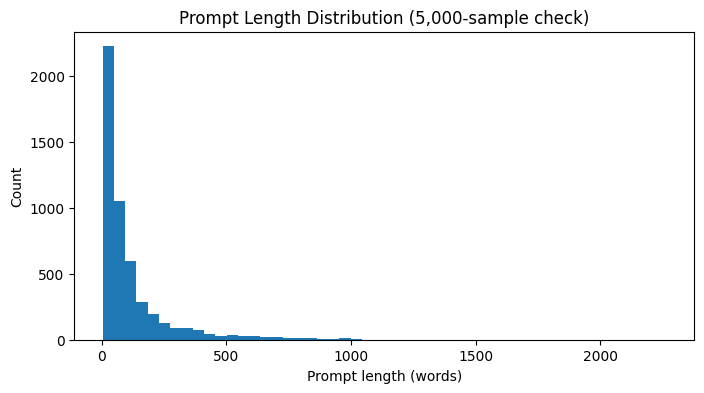


Total dataset size: 61135


In [2]:
import matplotlib.pyplot as plt

# ---- Convert a sample to a DataFrame for inspection ----
sample_size = min(5000, len(dataset))
sample_indices = random.sample(range(len(dataset)), sample_size)
sample = dataset.select(sample_indices)

df = pd.DataFrame({
    "prompt": sample["prompt"],
    "prompt_len": [len(p.split()) for p in sample["prompt"]],
})

print("Prompt length statistics (words):")
print(df["prompt_len"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["prompt_len"], bins=50)
plt.xlabel("Prompt length (words)")
plt.ylabel("Count")
plt.title("Prompt Length Distribution (5,000-sample check)")
plt.savefig("prompt_length_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal dataset size: {len(dataset)}")

## Cell 3 — Clean, Subsample (Tiered), and Save

In [3]:
import os

os.makedirs("data", exist_ok=True)

def extract_text(field):
    """UltraFeedback chosen/rejected are lists of turn dicts — extract final assistant text."""
    if isinstance(field, list):
        return field[-1]["content"] if isinstance(field[-1], dict) else str(field[-1])
    return str(field)

def build_pairs(hf_dataset, indices):
    pairs = []
    for i in indices:
        item = hf_dataset[i]
        pairs.append({
            "prompt": item["prompt"],
            "chosen": extract_text(item["chosen"]),
            "rejected": extract_text(item["rejected"])
        })
    return pairs

all_indices = list(range(len(dataset)))
random.shuffle(all_indices)

# ---- Tiered subsampling ----
sanity_indices = all_indices[:500]
main_indices = all_indices[:2500]          # includes sanity subset for consistency
scaling_indices = all_indices[:5000]        # optional, for later scaling experiment

sanity_pairs = build_pairs(dataset, sanity_indices)
main_pairs = build_pairs(dataset, main_indices)
scaling_pairs = build_pairs(dataset, scaling_indices)

# ---- Train/eval split (90/10) within each tier ----
def split_and_save(pairs, name):
    split_idx = int(0.9 * len(pairs))
    train, eval_ = pairs[:split_idx], pairs[split_idx:]
    with open(f"data/{name}_train.json", "w") as f:
        json.dump(train, f, indent=2)
    with open(f"data/{name}_eval.json", "w") as f:
        json.dump(eval_, f, indent=2)
    print(f"{name}: {len(train)} train / {len(eval_)} eval")

split_and_save(sanity_pairs, "sanity_500")
split_and_save(main_pairs, "main_2500")
split_and_save(scaling_pairs, "scaling_5000")

print("\nSaved all tiers to data/")

sanity_500: 450 train / 50 eval
main_2500: 2250 train / 250 eval
scaling_5000: 4500 train / 500 eval

Saved all tiers to data/
